In [1]:
import sys 
sys.path.insert(0, '../../')

In [3]:
from __future__ import annotations
import numpy as np
import pandas as pd
import scipy.stats as st
from dataclasses import dataclass

from matplotlib import pyplot as plt

from panel_exp.panel_data import long_df_to_paneldataset, PanelDataset, TimePeriod
from panel_exp.design import CompleteRandomization, ThinningDesign, Rerandomization, QuickBlock

In [4]:
from panel_exp.panel_data import long_df_to_paneldataset
from panel_exp.methods.tbr import TBR, TBRRidge
from panel_exp import panel_data

from panel_exp.inference.unit_jackknife import unit_jk

In [5]:
data = pd.read_csv('../data/google_sales.csv') 

In [6]:
pre_test_start = '2015-01-05'
pre_test_end   = '2015-02-15'

test_start = '2015-02-16'
test_end   = '2015-03-15'


In [7]:
wide_df = pd.pivot_table(data, index='geo', columns='date', values='sales', aggfunc=sum, fill_value=0)

In [8]:
treated_units = data[data.group==2].geo.unique()

In [9]:
wide_df 

date,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-10,2015-01-11,2015-01-12,2015-01-13,2015-01-14,...,2015-03-29,2015-03-30,2015-03-31,2015-04-01,2015-04-02,2015-04-03,2015-04-04,2015-04-05,2015-04-06,2015-04-07
geo,,,,,,,,,,,,,,,,,,,,,
1,7227.32,6815.22,6776.46,6576.36,6452.21,3131.31,2395.76,5673.50,5616.11,5938.80,...,2802.66,5529.79,10394.61,11034.58,14555.46,10089.66,4670.80,5486.67,11618.26,10236.80
2,5342.56,5952.46,6040.20,5539.52,5865.20,2413.62,2114.20,5807.51,4818.08,5342.42,...,2022.26,4978.16,9096.13,9292.64,12965.73,9827.24,4289.66,4805.18,10773.93,8906.44
3,4958.89,5263.24,5231.30,4634.11,4358.55,2443.12,1788.17,4219.14,4344.26,4415.26,...,2191.91,4120.10,8002.69,8455.96,12057.30,8556.54,4248.07,3796.85,8924.78,7260.99
4,4081.25,4130.58,3938.00,4069.46,3526.95,1558.29,1091.68,3290.93,3750.73,3843.93,...,1716.89,3343.74,6130.15,7132.35,9627.95,6726.44,3056.12,3164.04,7899.02,6098.67
5,2776.79,3084.68,2877.21,2667.54,2533.92,1420.65,1017.58,2705.21,2668.40,2410.60,...,1038.27,2247.32,4695.00,5013.22,7639.04,5255.47,2300.76,2239.18,4570.55,4110.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,9.59,19.28,24.22,24.34,44.02,4.92,9.88,14.89,29.92,10.02,...,0.00,27.24,34.17,61.72,34.41,34.53,20.79,20.87,76.75,49.01
97,0.00,14.46,24.22,24.34,9.78,24.58,9.88,9.93,14.97,35.08,...,6.79,20.43,27.33,54.87,61.93,27.62,48.51,20.87,41.86,35.01
98,4.80,24.10,43.59,38.95,4.90,9.83,9.88,9.93,19.95,20.04,...,6.79,34.05,41.00,27.43,68.82,75.96,27.72,13.91,48.84,49.01


In [10]:
pds = PanelDataset(wide_df
                , treated_periods=[TimePeriod(start=test_start, end=test_end) for _ in range(len(treated_units))]
                , treated_units=list(treated_units))

In [11]:
print(pds.summarize())


        Panel Dataset Summary
        ---------------------
        Number of time points: 93
        Number of units: 100
        Number of treated units: 50
        Treated units: [1, 12, 14, 15, 18, 20, 22, 24, 25, 27, 30, 31, 33, 35, 38, 4, 40, 42, 43, 46, 48, 49, 51, 53, 55, 57, 59, 6, 61, 64, 65, 67, 7, 70, 71, 73, 75, 77, 79, 81, 83, 85, 88, 9, 90, 92, 93, 96, 98, 99]
        Treated periods: [TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-15'), TimePeriod(start='2015-02-16', end='2015-03-1

In [12]:
# Plotting Functions

In [13]:
tbr = TBRRidge()
tbr.run_analysis(pds)

In [14]:
pds.treated_end_idxs[0]

69

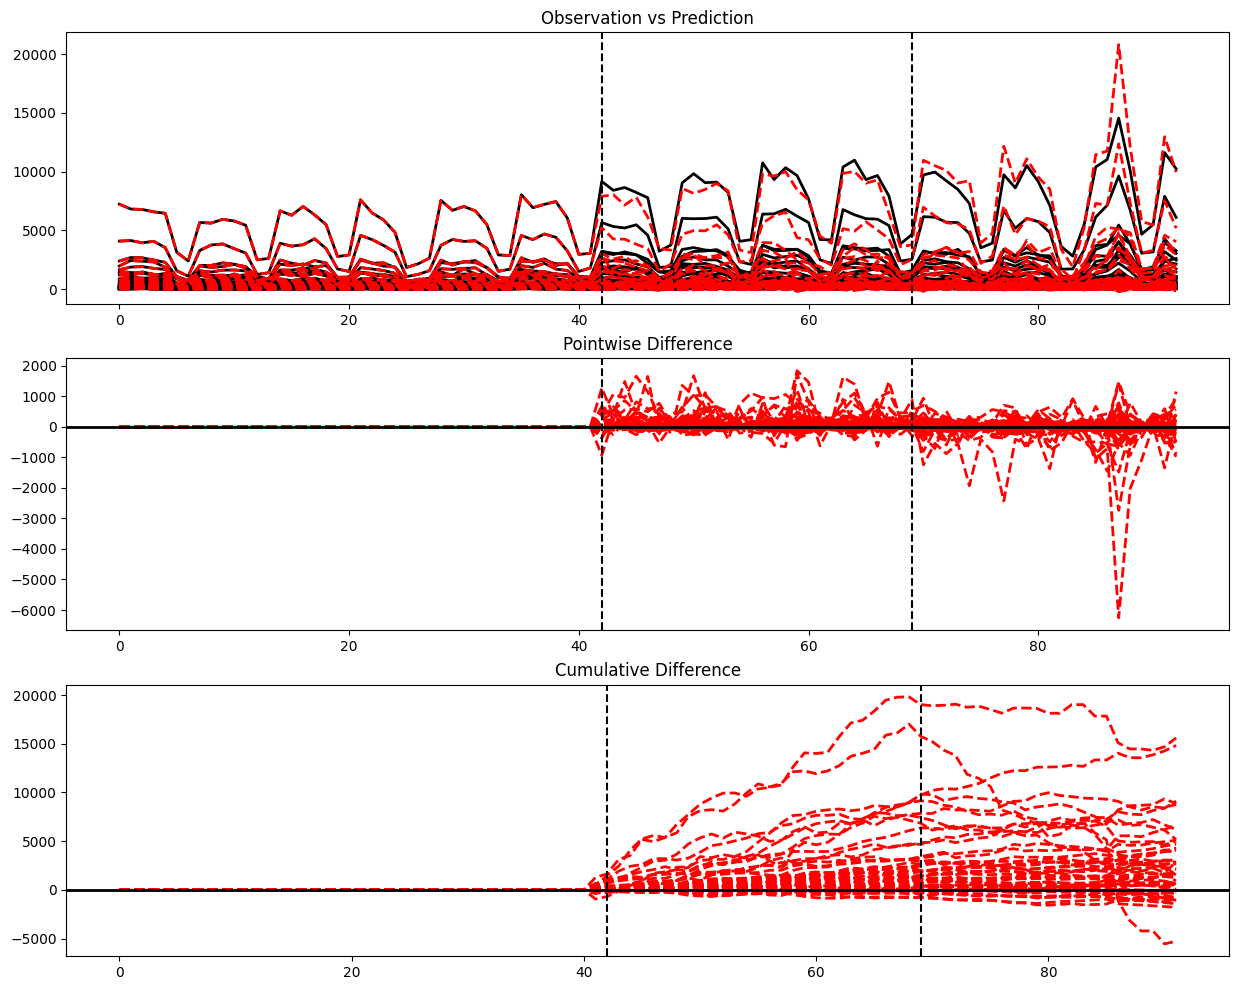

In [15]:
tbr.plot(legend=False)

In [16]:
print(test_start, test_end)

2015-02-16 2015-03-15


In [17]:
tbr.summary()

,Average,Cumulative
Actual,720.913237,973232.87
Predicted,621.288067,838738.891088
,,
Absolute Effect,99.62517,134493.978912
,,
Relative Effect,16.035262,16.035262


# Issue. 

1. Treated units have an end data associated with it, but plots aren't taking that into effect.
2. Neither are results.

Both of these should be simple fix. For summarize results function, just add a treatment mask to only calculate ATT for treated times. We can also include a cool down window. 

We'll have to update plotting functions as well. 

In [19]:
tbr.results

{'times': array(['2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
        '2015-01-09', '2015-01-10', '2015-01-11', '2015-01-12',
        '2015-01-13', '2015-01-14', '2015-01-15', '2015-01-16',
        '2015-01-17', '2015-01-18', '2015-01-19', '2015-01-20',
        '2015-01-21', '2015-01-22', '2015-01-23', '2015-01-24',
        '2015-01-25', '2015-01-26', '2015-01-27', '2015-01-28',
        '2015-01-29', '2015-01-30', '2015-01-31', '2015-02-01',
        '2015-02-02', '2015-02-03', '2015-02-04', '2015-02-05',
        '2015-02-06', '2015-02-07', '2015-02-08', '2015-02-09',
        '2015-02-10', '2015-02-11', '2015-02-12', '2015-02-13',
        '2015-02-14', '2015-02-15', '2015-02-16', '2015-02-17',
        '2015-02-18', '2015-02-19', '2015-02-20', '2015-02-21',
        '2015-02-22', '2015-02-23', '2015-02-24', '2015-02-25',
        '2015-02-26', '2015-02-27', '2015-02-28', '2015-03-01',
        '2015-03-02', '2015-03-03', '2015-03-04', '2015-03-05',
        '2015-03-06', '2015-03-